# Block 1: Meet Your Patient
### Temporally Entangled Documents DocEng '26 Tutorial

You met the puzzle in the intro: a heart monitor, a lab result, a doctor's note, three sources that don't agree on what time it is. This is where you take it apart, one real patient's whole story at a time, right down to the actual files a real hospital system would have handed you, and where you end up building something you keep: two PDFs, generated from the same patient, that make the difference between "collapsed time" and "engineered time" impossible to unsee.

Nothing here requires you to already know Python. Every cell is written, tested, and ready to run. Your job is to run it, look at what comes out, and then explore what happens when you change one thing. **Run it, watch it, break it, fix it.**

By the end of this block you'll have:
- Generated/loaded a synthetic ICU patient and watched their data sources drift out of sync
- Put an actual number on documentation lag, computed yourself, not handed to you
- Opened your patient's own real MUSE-format ECG file and FHIR export, and watched them get unified
- Seen a structured patient record become an actual *document*
- Pulled medication information out of raw text using character-level annotations, including a brand name your patient's own chart actually uses
- Rendered two PDFs from that same patient: one the naive way, one the document-engineered way, and seen exactly where they diverge

Nothing in this block is real patient data. Everything is synthetic, calibrated against real timing patterns.

## Setup

Run this once. It loads the data and the tools we built for this tutorial, including `pdf_report.py`, which is new for this block and does the final capstone build.

In [1]:
!rm -rf doceng26-pulse-and-paper
!git clone -q https://github.com/lbutler2405/doceng26-pulse-and-paper.git
DATA_DIR = "/content/doceng26-pulse-and-paper/"

%pip install -q reportlab jsonschema

import sys
sys.path.insert(0, DATA_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from viz import plot_patient_timeline, plot_event_window, plot_lag_by_tier
from document_representation import build_documents, render_markdown
from parse_muse_xml import parse_muse_xml, decode_all_leads
from parse_fhir_bundle import parse_fhir_bundle
from pdf_report import render_naive_pdf, render_engineered_pdf
from generate_amendments import resolve_as_of

TEAL, CORAL = "#028090", "#D96C6C"
DARK, SEAFOAM, AMBER = "#0A2E36", "#00A896", "#E1A82D"

print("Ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.2 MB/s eta 0:00:00
Ready.


## Why this is a document engineering problem

Quick example before you touch any data. Here's the same clinical event, written two ways.

**Naive:** *"Patient developed hypotension. Patient stable on routine check."*

**Engineered:** *"Hypotension observed 03:14, charted 07:52 (4.6h later). Routine check performed 05:30, charted 05:41 (11min later)."*

Both sentences are true. Both come from the same underlying facts. But only one of them tells you that the hypotension was charted nearly five hours after it happened, while the routine check that comes right after it in the naive version was actually charted first, at 05:41. Read the naive version and the routine check looks like it happened after the hypotension resolved. It didn't. It was charted eleven minutes after it happened, and it landed in the document *before* the hypotension note only because someone got around to writing the hypotension note late.

Nothing was hidden on purpose. Nobody lied. The information to reconstruct the real order was sitting right there in the two timestamps every EHR system already stores. It just wasn't *engineered* into the document. That gap, between the facts a system has and the facts a document actually surfaces, is the whole tutorial. Everything below is you doing that engineering by hand, once, for one patient, until you can feel exactly where it matters.

## Step 1: Meet your patient

Run the cell below and a synthetic ICU patient appears: a continuous vital-sign stream, a handful of lab results scattered irregularly through their stay, and a set of clinical notes written at various points, some close to the events they describe, some not.

This is the same corpus you toured in Block 0, but a different vantage point. Block 0 showed you the shape of all 75 patients at once, distributions, tier definitions, corpus-wide patterns. From here on you're looking at one patient's actual record, the way a clinician or an ingestion pipeline would encounter it: one chart, one stay, no aggregate statistics to lean on.

This particular patient was picked on purpose, they're one of a small number in this corpus with a real raw hospital export file sitting behind them, which is where this block is eventually headed.

Not every patient has both. Across the corpus:

- **Both ECG and echo (14):** 90000006, 90000015, 90000018, 90000019, 90000021, 90000022, 90000024, 90000027, 90000031, 90000048, 90000060, 90000061, 90000069, 90000073
- **ECG only (32):** 90000001, 90000003, 90000004, 90000005, 90000009, 90000011, 90000017, 90000023, 90000026, 90000028, 90000029, 90000033, 90000035, 90000036, 90000037, 90000038, 90000041, 90000044, 90000046, 90000049, 90000051, 90000053, 90000055, 90000057, 90000058, 90000059, 90000064, 90000065, 90000066, 90000067, 90000068, 90000072
- **Echo only (6):** 90000007, 90000012, 90000014, 90000016, 90000043, 90000062
- **Neither (23):** everyone else

Your default patient, 90000004, is ECG-only, that's why `plot_patient_timeline()` back in Step 2 never showed an echo row for them. If you want to see both diagnostic tracks together, or an echo-only patient, pick a `subject_id` from the lists above before you re-run.

In [ ]:
patients = pd.read_csv(f"{DATA_DIR}/data/synthetic_patients.csv")
# pick a patient to explore, feel free to change this later, see "Your turn" below
patient_id = 90000004
patient = patients[patients.subject_id == patient_id].iloc[0]

print(f"Patient {patient_id}")
print(f"  {patient.age} years old, {patient.gender}, admitted to {patient.careunit}")
print(f"  Reason for admission: {patient.admit_reason}")
print(f"  Comorbidities: {patient.comorbidities}")
print(f"  Complexity tier: {patient.hospital_complexity_tier}")
print(f"  Entanglement tier: {patient.entanglement_tier}")
print(f"  Population context: {patient.population_context}")
print(f"  Socioeconomic context: {patient.socioeconomic_context}")

ecg = pd.read_csv(f"{DATA_DIR}/data/synthetic_ecg_events.csv")
echo = pd.read_csv(f"{DATA_DIR}/data/synthetic_echo_events.csv")
has_ecg = patient_id in ecg.subject_id.values
has_echo = patient_id in echo.subject_id.values

if has_ecg and has_echo:
    diagnostics = "ECG and echo"
elif has_ecg:
    diagnostics = "ECG only"
elif has_echo:
    diagnostics = "echo only"
else:
    diagnostics = "no ECG or echo"
print(f"  Diagnostic studies: {diagnostics}")

Patient 90000004
  73 years old, M, admitted to CVICU
  Reason for admission: altered mental status
  Comorbidities: coronary artery disease
  Complexity tier: B_moderate
  Entanglement tier: high
  Population context: none
  Socioeconomic context: standard_resourced
  Diagnostic studies: ECG only


Notice what's *not* here: there's no column telling you whether this patient deteriorated, or when. That's deliberate. In a real hospital, nobody hands you the answer either, you have to work it out from the evidence, which is exactly what Block 2 is about. For now, we're just looking.

## Step 2: See the disagreement

This cell calls `plot_patient_timeline()`, a function in `viz.py` (imported back in Setup), and hands it nothing but your `patient_id`. Worth knowing what it actually does before you run it, since it's not a black box, it's ordinary matplotlib you could open and read yourself:

- It loads this one patient's rows out of the vitals, labs, notes, and ECG/echo CSVs.
- For every row that has *two* timestamps (a lab, a note, a diagnostic study), it draws **two markers connected by a line**: an open marker for when the thing actually happened, a filled marker for when it was recorded, and the line between them *is* the lag, drawn to scale. That convention repeats in every row, learn it once and you can read the whole figure.
- Colour does a second job everywhere it's used: teal/seafoam for a normal reading, coral for an abnormal one in the labs row, dark navy for ECG vs. teal for echo.

By default the tracks stack into one tall figure. If this patient has an ECG and an echo, they now get their own separate rows, each clearly labelled, rather than being merged into one ambiguous row. If the stacked text ever feels cramped, `plot_patient_timeline()` also takes `layout="separate"` (one self-contained figure per track, returned as a dict) or `layout="grid"` (all tracks in a grid, still one shared time axis), plus a `base_fontsize=` argument that scales everything at once. That's the same "give the user some power over the view" idea you'll see again at the end of this block, when you choose what goes into your own PDF.

If this patient had a deterioration event, you'll also see a shaded band, the window of time it could plausibly have started in. Every row carries its own legend explaining exactly what its markers and colours mean, so you shouldn't need this paragraph again after the first read.

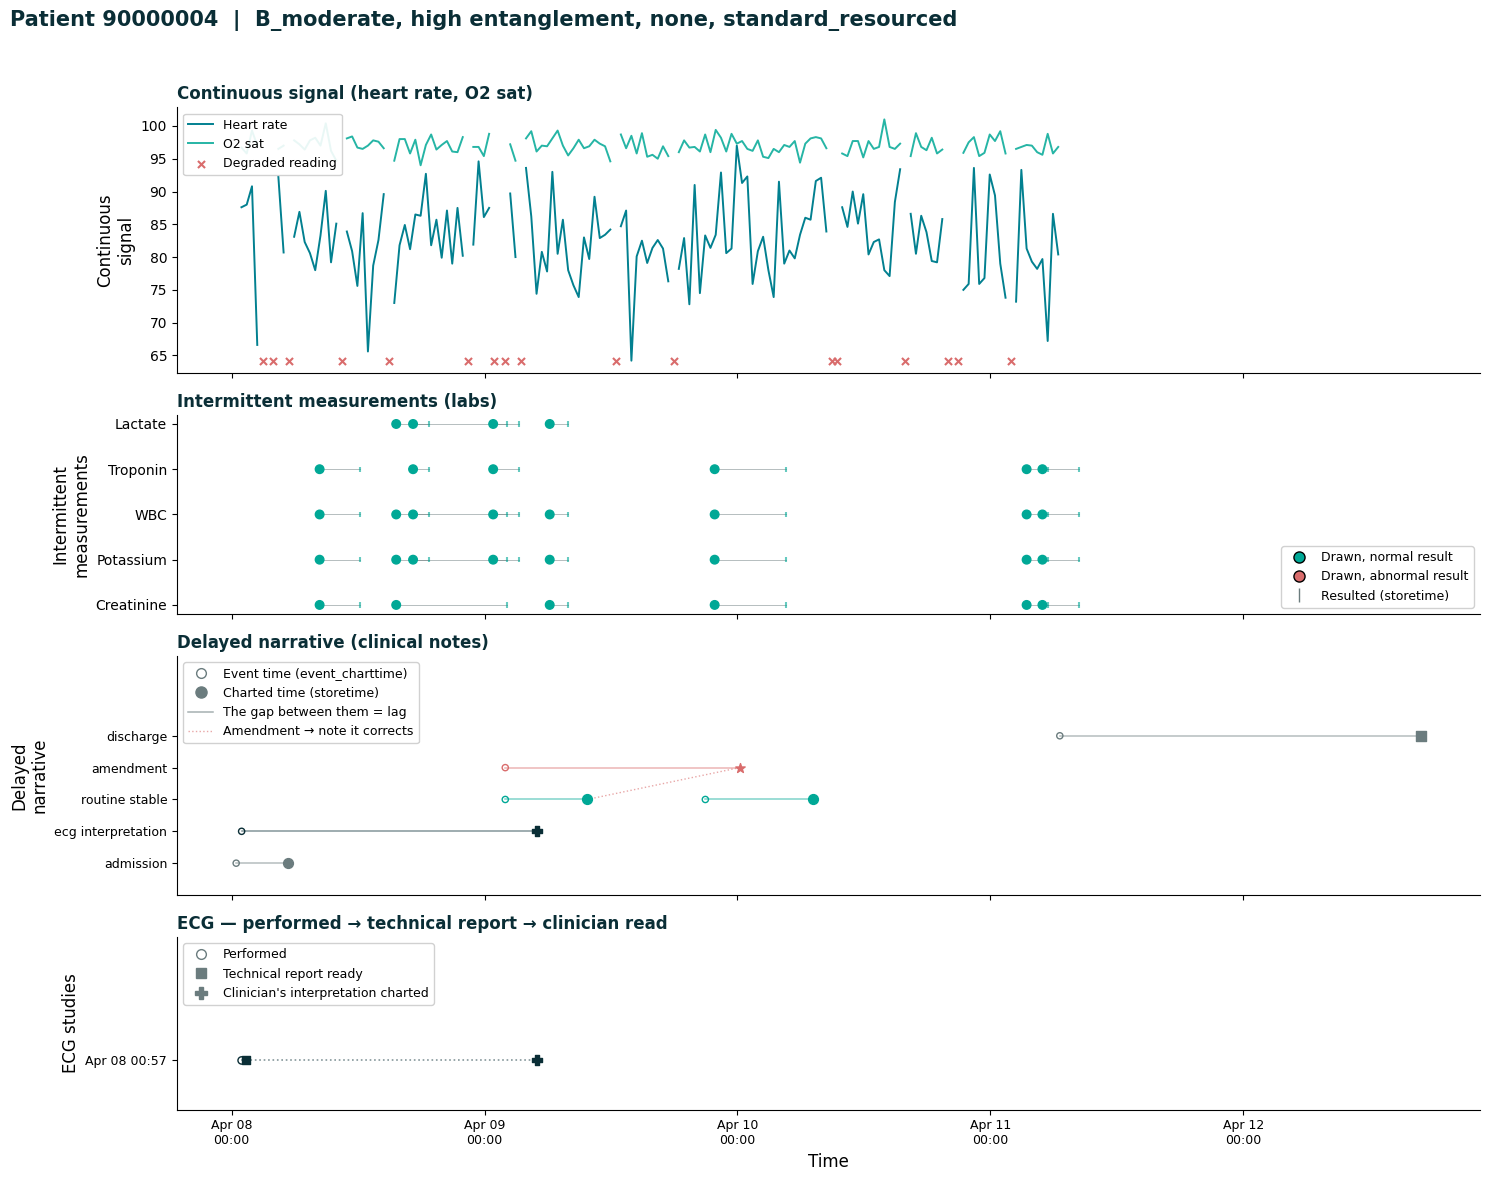

In [ ]:
fig = plot_patient_timeline(patient_id, data_dir=f"{DATA_DIR}/data", figsize=(15, 12))
plt.show()

Optional: same patient, laid out as a grid instead of stacked. Try it, then try `layout="separate"` too, it returns a dict of individual figures, one per track.

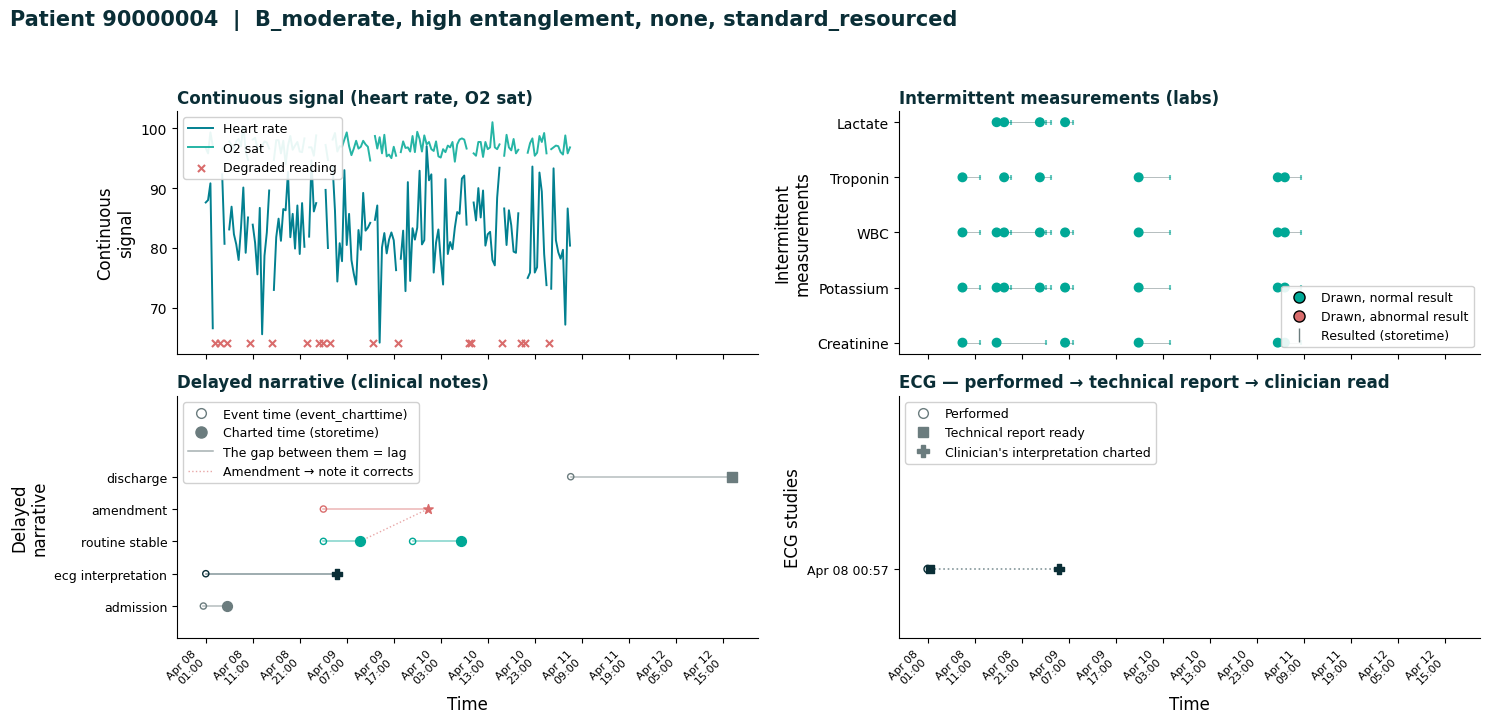

In [ ]:
fig = plot_patient_timeline(patient_id, data_dir=f"{DATA_DIR}/data", layout="grid", ncols=2)

import matplotlib.dates as mdates
for ax in fig.axes:
    if not ax.get_visible():
        continue
    lo, hi = ax.get_xlim()
    span_hours = (hi - lo) * 24
    if span_hours <= 24 * 8:
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=max(1, int(span_hours / 12))))
    elif span_hours <= 24 * 20:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, int(span_hours / 24 / 12))))
    else:
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=8, maxticks=14))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.show()

**What to look for:** the gap between the open circle and the filled marker on any note. That gap is documentation lag, and you're about to measure it directly instead of just eyeballing it. Notice that the gap isn't constant, some notes are charted minutes after the event, others hours. That variability is the thing Block 2's naive model will get fooled by.

## Step 3: Put a number on it

Real hospital systems don't hand you a "lag" column, because lag isn't a fact about the patient, it's a relationship between two timestamps that already exist in the record. Computing it is a small act of document engineering in itself: you're deriving a new, useful fact from a raw representation that never states it directly. Do it once by hand and you'll never again mistake "the record is silent on timing" for "timing doesn't matter."

In [ ]:
notes = pd.read_csv(f"{DATA_DIR}/data/synthetic_notes.csv", parse_dates=["event_charttime", "storetime"])
patient_notes = notes[notes.subject_id == patient_id].copy()

# this is the whole exercise: subtract the two timestamps every note already has
patient_notes["lag_hours"] = (patient_notes.storetime - patient_notes.event_charttime).dt.total_seconds() / 3600

patient_notes[["note_type", "event_charttime", "storetime", "lag_hours"]].sort_values("event_charttime")

,note_type,event_charttime,storetime,lag_hours
12,admission,2024-04-08 00:26:00,2024-04-08 05:23:00,4.950000
13,ecg_interpretation,2024-04-08 00:57:00,2024-04-09 04:56:00,27.983333
14,routine_stable,2024-04-09 01:58:00,2024-04-09 09:44:00,7.766667
15,amendment,2024-04-09 01:58:00,2024-04-10 00:12:00,22.233333
16,routine_stable,2024-04-09 20:57:00,2024-04-10 07:09:00,10.200000
17,discharge,2024-04-11 06:35:00,2024-04-12 16:50:00,34.250000


Look at the `lag_hours` column. This patient's entanglement tier is `low`, so the gap between something happening and someone charting it should be the shortest you'll see in this corpus. Compare that number to a patient with `high` entanglement (try it below) and the difference is the entire premise of Block 2, restated as one column of a DataFrame instead of a claim you're asked to take on faith.

## Your turn: try a different patient

Go back to Step 1, change `patient_id` to any `subject_id` from 90000001 to 90000075, and re-run Steps 1 through 3. Try picking one with a different `entanglement_tier` and watch how the lag numbers shift.

Related to something you already saw in Block 0: there, lag was split by *note type* (caregiver vs. overshadowed clinician notes, etc). Here it's split by *entanglement tier* instead, computed live from the same raw timestamps you just subtracted by hand, a different cut of the same underlying fact, so you can confirm your one patient isn't an outlier.

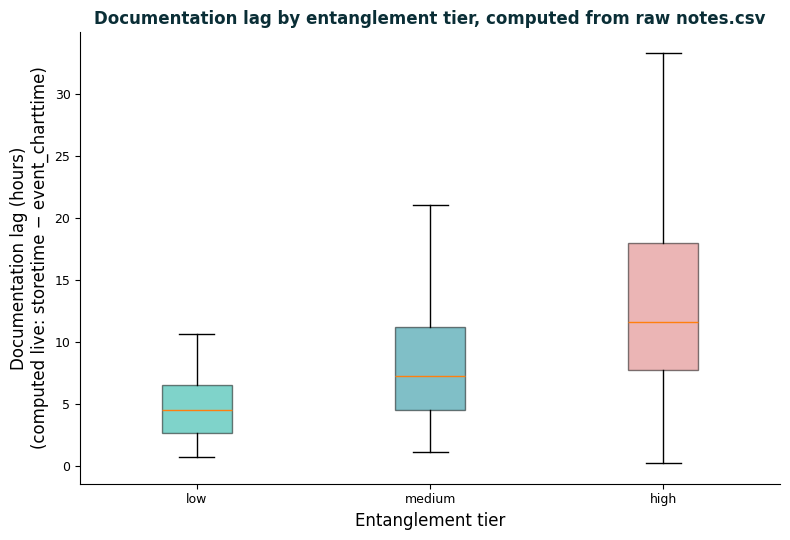

In [ ]:
fig = plot_lag_by_tier(data_dir=f"{DATA_DIR}/data")
plt.show()

## A real hospital export, for one specific patient

Block 0 already proved these raw formats are real and that `parse_muse_xml.py` / `parse_fhir_bundle.py` genuinely decode them. Only a handful of patients in this corpus have an actual raw file attached, most don't, real exports like these aren't something the tutorial can fabricate for all 75. So this section sticks to **patient 90000004 specifically, regardless of whichever `patient_id` you set above**, since 90000004 is one of the few with both a real MUSE XML and a real FHIR bundle on file.

If you want to explore further on your own, here's every patient with a real file attached, and its exact filename:

| `patient_id` | MUSE XML | FHIR bundle |
|---|---|---|
| 90000001 | `MUSE_90000001_ECG1.xml` | `fhir_bundle_90000001.json` |
| 90000003 | `MUSE_90000003_ECG2.xml` | `fhir_bundle_90000003.json` |
| 90000004 | `MUSE_90000004_ECG3.xml` | `fhir_bundle_90000004.json` |
| 90000006 | `MUSE_90000006_ECG5.xml` | `fhir_bundle_90000006.json` |
| 90000009 | `MUSE_90000009_ECG6.xml` | — |
| 90000017 | — | `fhir_bundle_90000017.json` |
| 90000019 | `MUSE_90000019_ECG15.xml` | — |
| 90000021 | `MUSE_90000021_ECG17.xml` | — |
| 90000036 | `MUSE_90000036_ECG30.xml` | — |
| 90000037 | `MUSE_90000037_ECG32.xml` | — |
| 90000044 | — | `fhir_bundle_90000044.json` |
| 90000061 | `MUSE_90000061_ECG51.xml` | — |

Every filename above sits under `{DATA_DIR}data/XML_JSON/muse_xml/` or `{DATA_DIR}data/XML_JSON/fhir_export/` respectively, same as the file used in the cell below. Any patient not in this table falls back to synthetic CSV rows, same as everything else in this corpus.

To look at a different real patient, don't change `patient_id`, this section does not read it. Instead, edit the filename directly in the cell below, swap `MUSE_90000004_ECG3.xml` for any filename from the MUSE column above (for the FHIR cell further down, do the same with the FHIR column).

In [ ]:
parsed_ecg = parse_muse_xml(f"{DATA_DIR}data/XML_JSON/muse_xml/MUSE_90000004_ECG3.xml")
for k, v in parsed_ecg.items():
    print(f"{k}: {v}")

subject_id: 90000004
finding: Sinus rhythm with occasional ectopy
rr_interval: 674
p_onset: 35.0
p_end: 139.0
qrs_onset: 183.0
qrs_end: 248.0
t_end: 446.0
p_axis: 72.0
qrs_axis: 47.0
t_axis: 55.0
decoded_waveform_peak_to_peak_uv: 1405.4
provenance: {'format': 'MUSE XML (GE Healthcare RestingECG)', 'source_system': 'Cardiology ECG acquisition system', 'raw_source_file': '/content/doceng26-pulse-and-paper/data/XML_JSON/muse_xml/MUSE_90000004_ECG3.xml'}


The cell below decodes a full rhythm waveform from **patient 90000003's** MUSE file, not 90000004's, a second real example. `parsed_ecg` above and the decoded waveform below are two different real patients, both parsed.

In [ ]:
leads, sample_rate_hz = decode_all_leads(f"{DATA_DIR}data/XML_JSON/muse_xml/MUSE_90000004_ECG3.xml", waveform_type="Rhythm")
print(f"Leads available in this file: {', '.join(leads.keys())}")

Leads available in this file: I, II, V1, V2, V3, V4, V5, V6


If you've never read an ECG before, those onset/offset numbers above (`p_onset`, `qrs_onset`, `t_end`...) probably don't mean much yet. They're milliseconds marking three phases of one heartbeat: the P wave (the atria contracting), the QRS complex (the ventricles contracting, the sharp spike you'd recognize from a monitor), and the T wave (the ventricles resetting). Rather than describe that, here it is labeled, using the exact numbers `parsed_ecg` just gave you, not typed in by hand.

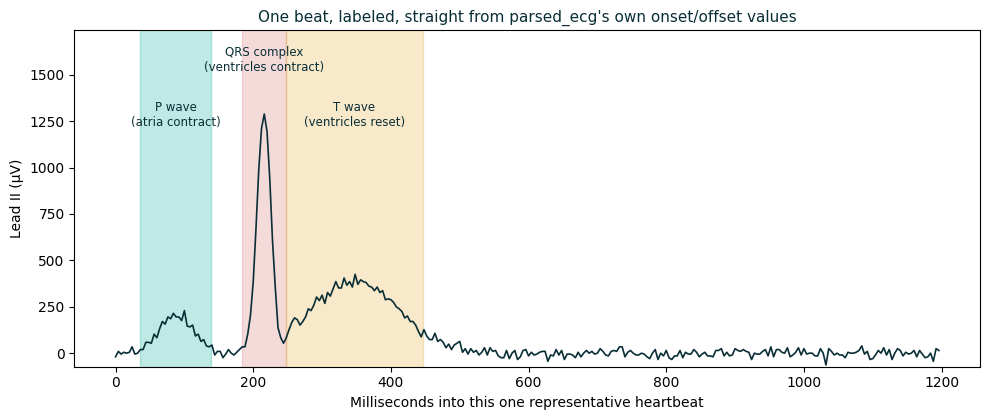

In [ ]:
leads_median, sr_median = decode_all_leads(f"{DATA_DIR}data/XML_JSON/muse_xml/MUSE_90000004_ECG3.xml", waveform_type="Median")
t_ms = np.arange(len(leads_median["II"])) / sr_median * 1000

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(t_ms, leads_median["II"], color=DARK, linewidth=1.2, zorder=3)

ymax = max(leads_median["II"]) * 1.35
ax.set_ylim(min(leads_median["II"]) * 1.15, ymax)

regions = [
    (parsed_ecg["p_onset"], parsed_ecg["p_end"], SEAFOAM, "P wave\n(atria contract)", 0.78),
    (parsed_ecg["qrs_onset"], parsed_ecg["qrs_end"], CORAL, "QRS complex\n(ventricles contract)", 0.95),
    (parsed_ecg["qrs_end"], parsed_ecg["t_end"], AMBER, "T wave\n(ventricles reset)", 0.78),
]
for start, end, color, label, height_frac in regions:
    ax.axvspan(start, end, color=color, alpha=0.25, zorder=1)
    ax.text((start + end) / 2, ymax * height_frac, label, ha="center", va="top", fontsize=8.5, color=DARK)

ax.set_xlabel("Milliseconds into this one representative heartbeat")
ax.set_ylabel("Lead II (\u00b5V)")
ax.set_title("One beat, labeled, straight from parsed_ecg's own onset/offset values", fontsize=11, color=DARK)
fig.tight_layout()
plt.show()

Now the real 10-second strip, multiple heartbeats. Watch for that same P-QRS-T shape repeating, now that you know what to look for.

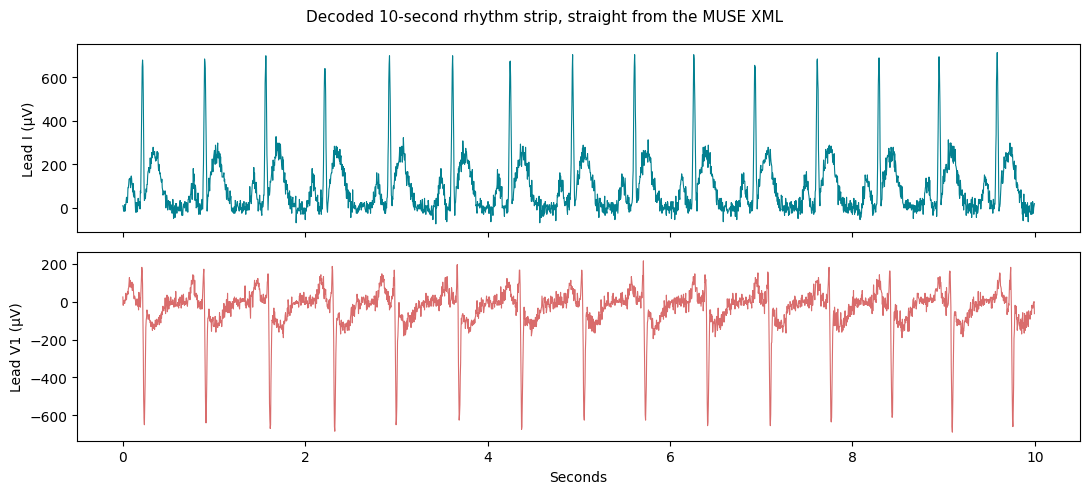

In [ ]:
import numpy as np
t = np.arange(len(leads["I"])) / sample_rate_hz

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, leads["I"], color=TEAL, linewidth=0.8)
axes[0].set_ylabel("Lead I (\u00b5V)")
axes[1].plot(t, leads["V1"], color=CORAL, linewidth=0.8)
axes[1].set_ylabel("Lead V1 (\u00b5V)")
axes[1].set_xlabel("Seconds")
fig.suptitle("Decoded 10-second rhythm strip, straight from the MUSE XML", fontsize=11)
fig.tight_layout()
plt.show()

Look back at that field list: `p_onset`, `qrs_onset`, `t_end`, all in milliseconds, all *within a single heartbeat*. That's temporal structure too, just at a wildly different scale than the hours-long documentation lag you measured in Step 3. A real clinical record has to handle both at once: milliseconds inside one waveform, hours across one stay. Document engineering doesn't get to pick a timescale.

That's patient 90000004's own heartbeat, decoded end to end, metadata, one labeled beat, and the full ten-second rhythm strip, all from the same real file. Now the other half: their vitals, labs, and notes also exist in a real FHIR R4 bundle, the second format from Block 0, parsed here for this same patient.

In [ ]:
parsed_fhir = parse_fhir_bundle(f"{DATA_DIR}data/XML_JSON/fhir_export/fhir_bundle_90000004.json")
print(f"Parsed from the real bundle: {len(parsed_fhir['vitals'])} vitals, {len(parsed_fhir['labs'])} labs, "
      f"{len(parsed_fhir['notes'])} notes, {len(parsed_fhir['medications'])} medications")

Parsed from the real bundle: 75 vitals, 32 labs, 5 notes, 4 medications


Two real formats, both now parsed for patient 90000004 specifically, same as every raw-file cell in this section. On to unifying them.

Notice `parsed_fhir["labs"]` and `["notes"]` carry the exact same event-time-vs-charted-time pair you've been measuring lag from since Step 3, just recovered from a completely different real-world format. The temporal entanglement problem doesn't change when the file format does, only the work of getting at it does.

## From data to document

One thing worth noting about before this next cell runs, it goes back to using whichever `patient_id` you set at Step 1 (`90000006` right now), not the hardcoded `MUSE_900000XX_ECGY.xml` from the raw-file cells just above. `document_representation.py` works for any patient in the corpus, real files or not, unlike `parse_muse_xml`/`parse_fhir_bundle`, which only exist for the handful with a genuine export attached.

You've already seen this schema's shape in Block 0, and confirmed with `synthetic_documents.json` that a pre-built document can honestly report where its own data came from. Here's that same assembly step, live, for your patient: `document_representation.py` takes the CSV rows, the MUSE-parsed ECG, and the FHIR-parsed vitals/labs/notes from the cells above, and unifies them into one schema-validated object, the formal structure this whole tutorial has been building toward.

This is also what makes Step 2's plot possible in the first place: once CSV rows, a MUSE-parsed ECG, and FHIR-parsed vitals sit in one schema, their timestamps are directly comparable on one shared axis, regardless of which format each one actually came from.

In [ ]:
all_documents = build_documents(f"{DATA_DIR}/data")
this_document = all_documents[str(int(patient.hadm_id))]

print(f"Document has {len(this_document['evidence_streams']['delayed_narrative']['notes'])} notes, "
      f"schema-validated, provenance-tagged.")

Document has 6 notes, schema-validated, provenance-tagged.


Same honesty as the provenance check in Block 0, just built live this time instead of read from a pre-made file: `continuous_signal` says `HL7 FHIR R4 Bundle` because it really was parsed from the bundle above, and the ECG says MUSE XML because it really was decoded from that file.

In [ ]:
print("Current patient_id:", patient_id)
print("this_document's subject_id:", this_document["subject_id"])

Current patient_id: 90000004
this_document's subject_id: 90000004


In [ ]:
from IPython.display import Markdown, display

chart = render_markdown(this_document)
display(Markdown(chart))

# Admission 92000004  (patient 90000004)

**73yo M**, CVICU, admitted for *altered mental status*
2024-04-08T00:26:00 → 2024-04-11T06:35:00

**Comorbidities:** coronary artery disease

**Design context:** B_moderate · high entanglement · none · standard_resourced

## Narrative timeline

**[admission]** (clinician) — event: `2024-04-08T00:26:00+00:00`, charted: `2024-04-08T05:23:00+00:00`
> Admitted from ED with altered mental status. Initial assessment stable. Continuing workup. Vitals reviewed on arrival, patient alert and oriented. Allergies reviewed, none reported. Plan: start levofloxacin 500mg, IV, daily for presumed infection. Patient and family updated on initial plan.

**[ecg_interpretation]** (clinician) — event: `2024-04-08T00:57:00+00:00`, charted: `2024-04-08T14:26:00+00:00`
> Reviewed today's ECG, sinus rhythm with occasional ectopy noted. Will trend with serial tracings.

**[routine_stable]** (clinician) — event: `2024-04-09T01:58:00+00:00`, charted: `2024-04-09T09:44:00+00:00`
> Overnight course unremarkable. Vitals within patient's usual range. Continue monitoring. Overnight vitals within the patient's acceptable range. Home medication apixaban (5mg, PO, BID) continued for atrial fibrillation. Family updated on plan of care at bedside.

**[routine_stable]** (clinician) — event: `2024-04-09T20:57:00+00:00`, charted: `2024-04-10T07:09:00+00:00`
> No acute changes overnight. Patient stable, tolerating current plan of care. Input and output balanced over the last shift. Continues on levofloxacin 500mg IV daily for presumed infection, tolerating well. Pain well controlled on current regimen.

**[discharge]** (clinician) — event: `2024-04-11T06:35:00+00:00`, charted: `2024-04-12T16:50:00+00:00`
> Patient's condition improved / stabilized over the admission. Discharged with follow-up plan in place. Discharge instructions reviewed with patient and family. Transportation home arranged with family. Discharge medications include levofloxacin 500mg IV daily for presumed infection. No acute issues at time of discharge. Follow-up appointment scheduled with primary care.

**[AMENDMENT → corrects 90000004-N14]** (clinician) — event: `2024-04-09T01:58:00`, charted: `2024-04-10T00:12:00` — *wrong drug charted, corrected to actual order*
> ADDENDUM to note 90000004-N14: medication was charted incorrectly. Corrected medication: furosemide (previously apixaban).
medication spans: MEDICATION=“furosemide”

## ECG studies

- 2024-04-08T00:57:00: Sinus rhythm with occasional ectopy (reported 2024-04-08T01:21:00)

## Summary counts

- 75 continuous vitals readings
- 32 lab draws
- 6 notes

That's a generated document, not a hand-written one. Every word in it traces back to a specific real file or a specific CSV row, but it's still something only you, sitting in this notebook, can see. It's not yet something a clinician could open on shift, or an auditor could file, or a family member could actually read. That's the last gap left to close, and it's the one the rest of this block is building toward: turning this structured object into a real, shareable document, twice, once the naive way and once the engineered way, so the difference between them stops being an argument and starts being something you can hold in two hands.

## Extracting structure from text: medication mentions

A sentence like *"Plan: start Prinivil 10mg, PO, daily for hypertension"* packs five separate pieces of structured information into one clause: which drug, what dose, how it's given, how often, and why. Real clinical notes read exactly like this, buried in prose, not laid out as fields.

`synthetic_medication_labels.csv` tells you exactly where each of those pieces sits in the text, as character positions, in the same format used by the real medication-labels-mimic-note dataset this is modeled on. Let's pull one of your patient's own mentions apart.

In [ ]:
med_labels = pd.read_csv(f"{DATA_DIR}/data/synthetic_medication_labels.csv")
display(med_labels.head(8))

,subject_id,note_id,Start Position,End Position,Annotation,Group,Text
0,90000001,90000001-N2,205,214,MEDICATION,1_0001N2,Lopressor
1,90000001,90000001-N2,215,219,DOSAGE,1_0001N2,25mg
2,90000001,90000001-N2,220,222,MODE,1_0001N2,PO
3,90000001,90000001-N2,223,226,FREQUENCY,1_0001N2,BID
4,90000001,90000001-N2,231,243,REASON,1_0001N2,rate control
5,90000001,90000001-N3,175,180,MEDICATION,1_0001N3,Lasix
6,90000001,90000001-N3,181,185,DOSAGE,1_0001N3,40mg
7,90000001,90000001-N3,186,188,MODE,1_0001N3,IV


In [ ]:
med_labels = pd.read_csv(f"{DATA_DIR}/data/synthetic_medication_labels.csv")

# prefer a note that uses one of the brand names Block 0's naive dictionary missed,
# if this patient has one, that's the more interesting example; otherwise take the first
brand_names = {"Lopressor", "Lasix", "Eliquis", "Prinivil"}
patient_meds = med_labels[med_labels.subject_id == patient_id]
brand_notes = patient_meds[(patient_meds.Annotation == "MEDICATION") & (patient_meds.Text.isin(brand_names))]
example_note_id = brand_notes.note_id.iloc[0] if len(brand_notes) else patient_meds.note_id.unique()[0]

example_text = notes[notes.note_id == example_note_id].text.iloc[0]
example_labels = med_labels[med_labels.note_id == example_note_id]

print(example_text)
print()

Admitted from ED with altered mental status. Initial assessment stable. Continuing workup. Vitals reviewed on arrival, patient alert and oriented. Allergies reviewed, none reported. Plan: start levofloxacin 500mg, IV, daily for presumed infection. Patient and family updated on initial plan.



In [ ]:
for _, row in example_labels.iterrows():
    span = example_text[row["Start Position"]:row["End Position"]]  # slice it ourselves
    assert span == row["Text"], "should always match the file's own Text column"
    print(f"  {row.Annotation:10s} -> \u201c{span}\u201d")

med_value = example_labels[example_labels.Annotation == "MEDICATION"].Text.iloc[0]
if med_value in brand_names:
    print(f"\n({med_value} is one of the exact brand names the Block 0 warm-up's naive dictionary "
          f"missed, until you taught it the synonym. Same corpus, same gap, now sitting inside this "
          f"patient's own real chart.)")
else:
    print(f"\n(This patient's own notes happen to use generic names throughout, {med_value} included, "
          f"no brand-name coincidence here, try a different patient_id if you want to hit one.)")

  MEDICATION -> “levofloxacin”
  DOSAGE     -> “500mg”
  MODE       -> “IV”
  FREQUENCY  -> “daily”
  REASON     -> “presumed infection”

(This patient's own notes happen to use generic names throughout, levofloxacin included, no brand-name coincidence here, try a different patient_id if you want to hit one.)


Whichever case printed above, the extraction itself does not change. Precise medication detail is exactly the kind of thing that gets lost when a summary is generated the naive way, and about to go straight into the document you are building next.

More generally, `text[start:end]` recovers the exact phrase every time, the labels aren't approximate, they're precise character offsets. This is the same span-to-text join you'd do with any annotated document corpus, legal contracts, financial filings, anything where you need to recover *which exact words* justify a structured claim.

## Not every note stays right, once it's charted

Block 0 showed you this corpus-wide: a rare but real second flaw in the narrative stream, distinct from lag. A note doesn't just arrive late sometimes, once in a while it arrives **wrong**, and someone has to go back and fix it. Let's see whether your patient has one.

In [ ]:
patient_amendments = notes[(notes.subject_id == patient_id) & (notes.note_type == "amendment")]

if len(patient_amendments):
    a = patient_amendments.iloc[0]
    orig = notes[notes.note_id == a.amends_note_id].iloc[0]
    print(f"Original note {orig.note_id}, charted {orig.storetime}:")
    print(f"  {orig.text}")
    print(f"\nAmendment {a.note_id}, charted {a.storetime}  ({a.amendment_reason}):")
    print(f"  {a.text}")
else:
    print(f"Patient {patient_id} doesn't have one. Patients that do, if you want to switch and re-run:")
    print(sorted(notes[notes.note_type == "amendment"].subject_id.unique()))

Original note 90000004-N14, charted 2024-04-09 09:44:00:
  Overnight course unremarkable. Vitals within patient's usual range. Continue monitoring. Overnight vitals within the patient's acceptable range. Home medication apixaban (5mg, PO, BID) continued for atrial fibrillation. Family updated on plan of care at bedside.

Amendment 90000004-N14-AMEND1, charted 2024-04-10 00:12:00  (wrong drug charted, corrected to actual order):
  ADDENDUM to note 90000004-N14: medication was charted incorrectly. Corrected medication: furosemide (previously apixaban).


Notice the amendment's own event time: copied straight from the note it corrects, not set to the moment the error was caught. The clinical event didn't move, only the documentation of it did, twice.

That creates a real question a raw timestamp comparison can't answer by itself: what did this chart actually *say*, at a given moment? Not "what does it say now", what did it say **as of** some specific point in time, before anyone had gone back to fix anything. `generate_amendments.py` ships a small helper for exactly this, `resolve_as_of()`, already imported back in Setup.

In [ ]:
if len(patient_amendments):
    before_notes, before_meds = resolve_as_of(notes, med_labels, as_of_time=orig.storetime + pd.Timedelta(hours=1))
    after_notes, after_meds = resolve_as_of(notes, med_labels, as_of_time=a.storetime + pd.Timedelta(hours=1))

    def prescription_string(meds_df, note_ids):
        """Later note_ids override earlier ones, field by field, so an amendment
        that only corrects one field (dosage, say) still shows the rest of the
        prescription intact, rather than showing nothing at all."""
        fields = {}
        for nid in note_ids:
            for _, row in meds_df[meds_df.note_id == nid].iterrows():
                fields[row.Annotation] = row.Text
        order = ["MEDICATION", "DOSAGE", "MODE", "FREQUENCY"]
        return " ".join(fields[k] for k in order if k in fields) or "(no medication mention found)"

    med_before = prescription_string(before_meds, [orig.note_id])
    med_after = prescription_string(after_meds, [orig.note_id, a.note_id])

    print(f"Medication on file 1 hour after the original note was charted: {med_before}")
    print(f"Medication on file 1 hour after the correction was charted:    {med_after}")
    print(f"\nSame patient, same query, two different true answers, depending only on when you asked.")
else:
    print("No amendment for this patient, nothing to compare, try a patient_id from the list above.")

Medication on file 1 hour after the original note was charted: apixaban 5mg PO BID
Medication on file 1 hour after the correction was charted:    furosemide 5mg PO BID

Same patient, same query, two different true answers, depending only on when you asked.


## Watch the schema catch a broken one

One more thing worth seeing before you build the actual document: `document_schema.json` doesn't just describe an amendment's shape, it enforces it. An amendment with no `amends_note_id` is an orphaned correction, a note that says "something earlier was wrong" without saying *what*. That should never validate, and it doesn't.

In [ ]:
print("Current patient_id:", patient_id)
print("Does this patient have an amendment in the raw CSV?",
      len(notes[(notes.subject_id == patient_id) & (notes.note_type == "amendment")]) > 0)
print("Does this_document actually contain one?",
      any(n.get("is_amendment") for n in this_document["evidence_streams"]["delayed_narrative"]["notes"]))
print("this_document's subject_id:", this_document["subject_id"])

Current patient_id: 90000004
Does this patient have an amendment in the raw CSV? True
Does this_document actually contain one? True
this_document's subject_id: 90000004


In [ ]:
import copy
from jsonschema import validate, ValidationError

with open(f"{DATA_DIR}/data/document_schema.json") as f:
    schema = json.load(f)

print("Validating your patient's real document, exactly as build_documents() produced it...")
try:
    validate(instance=this_document, schema=schema)
    print("  PASSED\n")
except ValidationError as e:
    print(f"  FAILED (unexpected): {e.message}\n")

print("Now deliberately orphaning the amendment, deleting amends_note_id...")
broken_document = copy.deepcopy(this_document)
broke_one = False
for n in broken_document["evidence_streams"]["delayed_narrative"]["notes"]:
    if n.get("is_amendment"):
        del n["amends_note_id"]
        broke_one = True
        break

if not broke_one:
    print("  This patient's document has no amendment to break, nothing was tested. Pick a patient_id")
    print("  from the amendment discovery cell above (Step 'Not every note stays right') and re-run from")
    print("  Step 1 to see this demo actually validate something.")
else:
    try:
        validate(instance=broken_document, schema=schema)
        print("  PASSED (this should not happen)")
    except ValidationError as e:
        print(f"  REJECTED, as it should be: {e.message}")

Validating your patient's real document, exactly as build_documents() produced it...
  PASSED

Now deliberately orphaning the amendment, deleting amends_note_id...
  REJECTED, as it should be: 'amends_note_id' is a required property


## Build your own engineered document

You've now done every piece of engineering this document needs by hand: measured the lag, parsed two raw hospital formats, watched them get unified into one schema-validated object, and pulled exact medication detail out of raw text. `pdf_report.py` renders that same evidence into an actual PDF, twice, on purpose.

If your patient has an amendment, it'll show up automatically in the engineered PDF's own "Corrections & Amendments" section, no extra step needed, that section only appears when there's something to say.

First, the naive version: what you'd get if nobody had done any of the above. One timestamp per fact. Notes in charting order. No event window. It's meant to look completely plausible, because that's the trap: a document can be well-formatted, professional-looking, and still be quietly wrong about when things happened.

In [ ]:
naive_path = render_naive_pdf(patient_id, data_dir=f"{DATA_DIR}/data",
                               save_path=f"{DATA_DIR}naive_summary_{patient_id}.pdf")
print(f"Naive summary saved to: {naive_path}")
print("(that's on this Colab machine, not your computer yet, a download cell for all three PDFs comes right after the third one)")
print("Open it. Look for: one date per fact, notes in the order they were charted rather than")
print("the order they happened, and no indication anywhere that an event window even exists.")

Naive summary saved to: /content/doceng26-pulse-and-paper/naive_summary_90000004.pdf
(that's on this Colab machine, not your computer yet, a download cell for all three PDFs comes right after the third one)
Open it. Look for: one date per fact, notes in the order they were charted rather than
the order they happened, and no indication anywhere that an event window even exists.


Now the engineered version. Same patient, same underlying facts, but rendered with everything you've built in this block: both timestamps on every fact, the possible event window shown rather than hidden, the narrative ordered by when things happened rather than when they were typed up, and medication detail pulled from the exact spans you just extracted.

You choose what goes in. `sections` is a plain dict, flip anything to `False` to leave it out, this is the same "power to the user" idea from `plot_patient_timeline()` back in Step 2, now applied to the document itself rather than just the plot.

In [ ]:
sections = dict(
    demographics=True,
    vitals_chart=True,
    labs=True,
    notes_timeline=True,
    medications=True,
    ecg=True,
    echo=True,
)

engineered_path = render_engineered_pdf(patient_id, data_dir=f"{DATA_DIR}/data", sections=sections,
                                         save_path=f"{DATA_DIR}engineered_report_{patient_id}.pdf",
                                         work_dir=DATA_DIR)
print(f"Engineered report saved to: {engineered_path}")
print("(same as the naive one, this is on the Colab machine for now, the download cell after the third PDF gets all three)")

Engineered report saved to: /content/doceng26-pulse-and-paper/engineered_report_90000004.pdf
(same as the naive one, this is on the Colab machine for now, the download cell after the third PDF gets all three)


One more version worth building, if your patient has an amendment: the record frozen at an earlier moment, before the correction existed. `render_engineered_pdf()` takes an `as_of_time` argument that does exactly what `resolve_as_of()` did above, but for the whole document at once, amendments charted after that moment simply aren't visible yet, because they weren't visible to anyone reading the chart at that moment either.

In [ ]:
if len(patient_amendments):
    asof_path = render_engineered_pdf(patient_id, data_dir=f"{DATA_DIR}/data", sections=sections,
                                       save_path=f"{DATA_DIR}engineered_report_{patient_id}_asof.pdf",
                                       work_dir=DATA_DIR, as_of_time=orig.storetime + pd.Timedelta(hours=1))
    print(f"As-of report saved to: {asof_path}")
    print("(still just on the Colab machine, this is the last of the three, the download cell is next)")
    print("Open it next to the current-state one. Same patient, same generator, one fact genuinely disagrees.")
else:
    asof_path = None
    print("No amendment for this patient, skip this one, or switch patient_id above and re-run from Step 1.")

As-of report saved to: /content/doceng26-pulse-and-paper/engineered_report_90000004_asof.pdf
(still just on the Colab machine, this is the last of the three, the download cell is next)
Open it next to the current-state one. Same patient, same generator, one fact genuinely disagrees.


Open the PDFs side by side. Same patient, same underlying evidence, and the naive and engineered ones should look like two different documents, because as far as what they claim about *when* things happened, they are. If your patient has an amendment, compare the current-state engineered PDF to the as-of one too, one fact between them genuinely disagrees, on purpose.

That's the entire tutorial in these files: the naive one is the failure mode Block 2's model is going to fall for, and the engineered ones are what it takes, concretely, to avoid it, including the version of "avoid it" that most tutorials never touch: knowing which version of the truth you're even looking at.

If you're running this in Colab, the cell below will trigger a download for all of them.

In [ ]:
try:
    from google.colab import files

    downloads = [
        ("Naive summary", naive_path),
        ("Engineered report", engineered_path),
        ("As-of report", asof_path),
    ]

    print("Downloading:")
    for label, path in downloads:
        if path:
            files.download(path)
            print(f"  - {label}: {path.split('/')[-1]}")

    print("\nThese should land in your browser's default download location, usually your computer's")
    print("Downloads folder, unless you've set your browser to ask each time or save somewhere else.")
    print("Search your file explorer for the filenames above if you're not sure where they went.")
except ImportError:
    print("Not running in Colab, your PDFs are already saved locally at the paths printed above.")

Downloading:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Naive summary: naive_summary_90000004.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Engineered report: engineered_report_90000004.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - As-of report: engineered_report_90000004_asof.pdf

These should land in your browser's default download location, usually your computer's
Downloads folder, unless you've set your browser to ask each time or save somewhere else.
Search your file explorer for the filenames above if you're not sure where they went.


## What you built

- A synthetic patient's multi-track timeline, plotted and read, in whichever layout actually made it legible
- A documentation-lag number, computed by hand from raw timestamps, not handed to you
- The same lag pattern, confirmed across all 75 patients
- Your patient's actual ECG waveform, decoded live from a real MUSE XML file, and their vitals and labs, genuinely parsed from a real FHIR bundle
- A structured, schema-validated document object built from those real sources, with provenance you verified yourself, not asserted
- A medication mention, pulled apart into five labeled, exactly-recoverable spans, including a brand name you'd already caught once before
- Two or three PDFs, built from that same patient: naive, document-engineered, and, if your patient had one, the record frozen as-of a moment before a correction existed, sitting on your disk right now so you can open them and see exactly where they diverge
- Proof, watched happen twice, that a document isn't just late sometimes, it can be *wrong* and then corrected, and that document_schema.json actually enforces what a valid correction has to say

That last one is the point of this whole block: "temporal entanglement is a document engineering problem" stops being a claim in a slide deck the moment you're holding two versions of the same patient's record and only one of them tells the truth about time.

None of this involved a model. That's Block 2, next: training something on data shaped exactly like this, and watching it initially get the wrong idea about why patients deteriorate.